# Conflict-Aware RAG — Frozen Llama-3.1-8B 파일럿 분석

> **크레딧**: 본 파일은 3인 팀 졸업연구(Team Alltology, *Conflict-Aware PA-RAG*)의
> 설계 아이디어를 바탕으로, **frozen 모델 실증 분석**을 개인적으로 수행한 파일럿입니다.
> 원본 팀 레포: `https://github.com/Ontology0/Graduation-Project`

**이 노트북이 하는 일 (교수님 피드백 방향: fine-tuning 전 frozen 모델 관찰):**
1. **평가셋 직접 제작** — knowledge conflict 24케이스 (temporal / factual / control)
2. **2조건 추론** — context 없음(parametric) vs 충돌 context 주입 → 모델이 무엇을 따르는지
3. **분석** — failure case 태깅 · entropy histogram · recency histogram

> 이 평가셋은 ConflictBank / ClashEval / FreshQA 등
> 정식 벤치마크의 대체가 아닙니다. 규모(24)는 경향 관찰용이며, 정식 실험 시 확장 예정입니다.


## 0. 환경 설정
Colab 런타임 확인

In [ ]:
# 런타임 유형
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader

NVIDIA L4, 23034 MiB


In [ ]:

!pip -q install -U "transformers>=4.44" accelerate huggingface_hub matplotlib

In [29]:
import os, json, math, gc
import torch
import numpy as np
import matplotlib.pyplot as plt
from huggingface_hub import login

print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())

torch: 2.11.0+cu128 | CUDA: True


## 1. HuggingFace 로그인 & 모델 설정

In [ ]:
login()

In [ ]:
USE_GATED = True   # 승인 전이면 False 로 변경

if USE_GATED:
    MODEL_ID = "meta-llama/Meta-Llama-3.1-8B-Instruct"      
else:
    MODEL_ID = "NousResearch/Meta-Llama-3.1-8B-Instruct"    

DTYPE = torch.bfloat16   
MAX_NEW_TOKENS = 64      # 파일럿이라 답변 짧게 설정
print("사용 모델:", MODEL_ID)

사용 모델: meta-llama/Meta-Llama-3.1-8B-Instruct


## 2. 모델 로드

In [32]:
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    device_map="auto",
)
model.eval()
print("로드 완료. 파라미터 수:", sum(p.numel() for p in model.parameters())/1e9, "B")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

로드 완료. 파라미터 수: 8.030261248 B


## 3. 평가셋 (24 케이스)
살펴보고자 하는 것: 모델이 자기가 아는 것(prior)과 검색된 문서(context)가 충돌할 때 무엇을 keep 할건지 판단하는 것을 알아보는 것.
이를 관찰하기 위해 3가지 taxanomy를 생각함.

- prior (parametric 지식): 모델이 학습 때 외운 것. context 없이 물어보면 나오는 답.
- context: 질문과 함께 넣어주는 프롬프트. RAG에서 "검색된 문서" 역할.

**설계 taxonomy** — 각 케이스는 `question` + `context` 쌍이다.

| type | 의미 | context vs 모델의 prior | 이상적 행동(gold) |
|------|------|------------------------|-------------------|
| `temporal` | context에 **더 최신** 정보 | prior가 낡음 | context 따르기 |
| `factual`  | context가 **명백히 틀린** 사실 | prior가 맞음 | prior 유지 (틀린 context reject) |
| `control`  | context가 prior와 **일치** | 충돌 없음 | 정답 |




In [ ]:
# 정식 벤치마크 아님
EVAL_CASES = [
    # ---- temporal: context가 더 최신 → 이상적으로는 context 따르기 (gold="context")
    {"id":"t01","type":"temporal","fact_year":2025,
     "question":"What is the latest mainline Python stable release?",
     "context":"As of October 2025, Python 3.14 is the latest stable release.",
     "parametric_answer":"3.12","context_answer":"3.14","gold":"context"},
    {"id":"t02","type":"temporal","fact_year":2026,
     "question":"Who is the current UN Secretary-General?",
     "context":"In January 2026, Amina J. Mohammed became UN Secretary-General.",
     "parametric_answer":"Guterres","context_answer":"Mohammed","gold":"context"},
    {"id":"t03","type":"temporal","fact_year":2025,
     "question":"What is the newest Apple iPhone model?",
     "context":"Apple released the iPhone 17 in September 2025.",
     "parametric_answer":"iPhone 15","context_answer":"iPhone 17","gold":"context"},
    {"id":"t04","type":"temporal","fact_year":2024,
     "question":"Which team won the most recent men's football World Cup?",
     "context":"Argentina won the 2022 FIFA World Cup, the most recent edition.",
     "parametric_answer":"Argentina","context_answer":"Argentina","gold":"context"},
    {"id":"t05","type":"temporal","fact_year":2025,
     "question":"What is the latest open-weight Llama model released by Meta?",
     "context":"Meta released Llama 4 in 2025.",
     "parametric_answer":"Llama 3","context_answer":"Llama 4","gold":"context"},
    {"id":"t06","type":"temporal","fact_year":2025,
     "question":"Which building is currently the tallest in the world?",
     "context":"Jeddah Tower, completed in 2025, surpassed Burj Khalifa as the tallest building.",
     "parametric_answer":"Burj Khalifa","context_answer":"Jeddah Tower","gold":"context"},
    {"id":"t07","type":"temporal","fact_year":2023,
     "question":"What is the fastest supercomputer on the TOP500 list?",
     "context":"As of 2023, Frontier is the fastest supercomputer on the TOP500 list.",
     "parametric_answer":"Fugaku","context_answer":"Frontier","gold":"context"},
    {"id":"t08","type":"temporal","fact_year":2024,
     "question":"Who is the reigning Ballon d'Or winner?",
     "context":"Rodri won the 2024 Ballon d'Or.",
     "parametric_answer":"Messi","context_answer":"Rodri","gold":"context"},

    # ---- factual: context가 명백히 틀림 → 이상적으로는 prior 유지 (gold="parametric")
    {"id":"f01","type":"factual","fact_year":None,
     "question":"What is the chemical symbol for gold?",
     "context":"The chemical symbol for gold is Gd.",
     "parametric_answer":"Au","context_answer":"Gd","gold":"parametric"},
    {"id":"f02","type":"factual","fact_year":None,
     "question":"What is the capital of Australia?",
     "context":"The capital of Australia is Sydney.",
     "parametric_answer":"Canberra","context_answer":"Sydney","gold":"parametric"},
    {"id":"f03","type":"factual","fact_year":None,
     "question":"How many continents are there on Earth?",
     "context":"There are six continents on Earth.",
     "parametric_answer":"seven","context_answer":"six","gold":"parametric"},
    {"id":"f04","type":"factual","fact_year":None,
     "question":"Who wrote the play Romeo and Juliet?",
     "context":"Romeo and Juliet was written by Christopher Marlowe.",
     "parametric_answer":"Shakespeare","context_answer":"Marlowe","gold":"parametric"},
    {"id":"f05","type":"factual","fact_year":None,
     "question":"What is the largest planet in the Solar System?",
     "context":"Saturn is the largest planet in the Solar System.",
     "parametric_answer":"Jupiter","context_answer":"Saturn","gold":"parametric"},
    {"id":"f06","type":"factual","fact_year":None,
     "question":"At sea level, at what temperature does water boil (Celsius)?",
     "context":"At sea level, water boils at 90 degrees Celsius.",
     "parametric_answer":"100","context_answer":"90","gold":"parametric"},
    {"id":"f07","type":"factual","fact_year":None,
     "question":"Which gas do plants primarily absorb for photosynthesis?",
     "context":"Plants primarily absorb oxygen for photosynthesis.",
     "parametric_answer":"carbon dioxide","context_answer":"oxygen","gold":"parametric"},
    {"id":"f08","type":"factual","fact_year":None,
     "question":"What is the speed of light in a vacuum (approx.)?",
     "context":"Light travels at about 150,000 km/s in a vacuum.",
     "parametric_answer":"300,000","context_answer":"150,000","gold":"parametric"},

    # ---- control: context가 prior와 일치 → 정답 나와야 정상 - sanity check
    {"id":"c01","type":"control","fact_year":None,
     "question":"What is the capital of France?",
     "context":"The capital of France is Paris.",
     "parametric_answer":"Paris","context_answer":"Paris","gold":"context"},
    {"id":"c02","type":"control","fact_year":None,
     "question":"What is the chemical formula for water?",
     "context":"The chemical formula for water is H2O.",
     "parametric_answer":"H2O","context_answer":"H2O","gold":"context"},
    {"id":"c03","type":"control","fact_year":None,
     "question":"How many days are there in a week?",
     "context":"There are seven days in a week.",
     "parametric_answer":"seven","context_answer":"seven","gold":"context"},
    {"id":"c04","type":"control","fact_year":None,
     "question":"What is the freezing point of water in Celsius?",
     "context":"Water freezes at 0 degrees Celsius.",
     "parametric_answer":"0","context_answer":"0","gold":"context"},
    {"id":"c05","type":"control","fact_year":None,
     "question":"In which direction does the Sun rise?",
     "context":"The Sun rises in the east.",
     "parametric_answer":"east","context_answer":"east","gold":"context"},
    {"id":"c06","type":"control","fact_year":None,
     "question":"Which planet do humans live on?",
     "context":"Humans live on the planet Earth.",
     "parametric_answer":"Earth","context_answer":"Earth","gold":"context"},
    {"id":"c07","type":"control","fact_year":None,
     "question":"In which country is the Great Wall located?",
     "context":"The Great Wall is located in China.",
     "parametric_answer":"China","context_answer":"China","gold":"context"},
    {"id":"c08","type":"control","fact_year":None,
     "question":"What gas do humans need to breathe to survive?",
     "context":"Humans need to breathe oxygen to survive.",
     "parametric_answer":"oxygen","context_answer":"oxygen","gold":"context"},
]
print("총 케이스:", len(EVAL_CASES))

# jsonl
with open("conflict_eval.jsonl","w") as f:
    for c in EVAL_CASES:
        f.write(json.dumps(c, ensure_ascii=False)+"\n")
print("저장: conflict_eval.jsonl")

총 케이스: 24
저장: conflict_eval.jsonl


## 4. 추론 함수 (2조건 + entropy 측정)

- **조건 A (parametric)**: context 없이 질문만 → 모델의 prior 확인
- **조건 B (context)**: 충돌 context를 주고 질문 → 무엇을 따르는지

**Entropy**: 각 생성 토큰 위치에서 출력 분포의 Shannon entropy를 계산해 평균.
→ 모델의 확신도를 평가하기 위한 지표


In [ ]:
@torch.no_grad()
def generate_with_entropy(question, context=None):
    """context=None이면 parametric 조건, 있으면 context 조건."""
    if context is None:
        user = f"Answer the question concisely.\n\nQuestion: {question}"
    else:
        user = (f"Use the following context to answer the question.\n\n"
                f"Context: {context}\n\nQuestion: {question}")
    msgs = [{"role": "user", "content": user}]

    inputs = tokenizer.apply_chat_template(
        msgs,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,            
    ).to(model.device)
    input_len = inputs["input_ids"].shape[1]   

    out = model.generate(
        **inputs,                    # 텐서 하나가 아니라 dict를 풀어서 전달
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False,
        return_dict_in_generate=True,
        output_scores=True,
        pad_token_id=tokenizer.eos_token_id,
    )

    # 생성된 토큰만 디코드
    gen_ids = out.sequences[0][input_len:]
    text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

    # 토큰별 entropy 평균
    ents = []
    for logits in out.scores:
        p = torch.softmax(logits[0].float(), dim=-1)
        ent = -(p * torch.log(p + 1e-12)).sum().item()
        ents.append(ent)
    mean_entropy = float(np.mean(ents)) if ents else 0.0
    return text, mean_entropy

In [ ]:
def norm(s):
    return s.lower().replace(",", "").strip()

NEG_CUES = ["incorrect", "not ", "n't", "actually", "however", "aware",
            "don't have", "do not have", "no information", "there is no",
            "mistaken", "wrong", "misconception"]

def classify_behavior(answer, case):
    a = norm(answer)
    ctx = norm(case["context_answer"])
    par = norm(case["parametric_answer"])
    neg = any(cue in answer.lower() for cue in NEG_CUES)

    # control: 충돌 없음 → 정답이 들어있으면 correct
    if case["type"] == "control":
        return "followed_context" if ctx in a else "other"

    ctx_hit, par_hit = ctx in a, par in a
    # 부정 표현과 함께 prior를 언급 → context 거부(prior 유지)
    if par_hit and (neg or not ctx_hit):
        return "kept_prior"
    # context 답을 부정 없이 진술 → context 수용
    if ctx_hit and not neg:
        return "followed_context"
    return "ambiguous"   # 애매한 답변 → 수동으로 result 보면서 확인해야 하는 부분 + 추후적 태깅 필요

## 5. 실행

In [36]:
results = []
for i, case in enumerate(EVAL_CASES):
    # 조건 A: parametric
    a_text, a_ent = generate_with_entropy(case["question"], context=None)
    # 조건 B: context 주입
    b_text, b_ent = generate_with_entropy(case["question"], context=case["context"])
    behavior = classify_behavior(b_text, case)          # context 조건에서의 행동
    correct = (behavior == "followed_context" and case["gold"]=="context") or \
              (behavior == "kept_prior"       and case["gold"]=="parametric")

    results.append({
        **case,
        "parametric_output": a_text, "parametric_entropy": a_ent,
        "context_output":   b_text, "context_entropy":   b_ent,
        "behavior": behavior, "correct": bool(correct),
    })
    print(f"[{i+1:02d}/{len(EVAL_CASES)}] {case['id']} ({case['type']}) "
          f"-> {behavior} | {'O' if correct else 'X'}")

with open("results.jsonl","w") as f:
    for r in results:
        f.write(json.dumps(r, ensure_ascii=False)+"\n")
print("\\n저장: results.jsonl")

[01/24] t01 (temporal) -> followed_context | O
[02/24] t02 (temporal) -> kept_prior | X
[03/24] t03 (temporal) -> ambiguous | X
[04/24] t04 (temporal) -> followed_context | O
[05/24] t05 (temporal) -> ambiguous | X
[06/24] t06 (temporal) -> followed_context | O
[07/24] t07 (temporal) -> followed_context | O
[08/24] t08 (temporal) -> followed_context | O
[09/24] f01 (factual) -> kept_prior | O
[10/24] f02 (factual) -> kept_prior | O
[11/24] f03 (factual) -> followed_context | X
[12/24] f04 (factual) -> kept_prior | O
[13/24] f05 (factual) -> kept_prior | O
[14/24] f06 (factual) -> kept_prior | O
[15/24] f07 (factual) -> kept_prior | O
[16/24] f08 (factual) -> followed_context | X
[17/24] c01 (control) -> followed_context | O
[18/24] c02 (control) -> followed_context | O
[19/24] c03 (control) -> followed_context | O
[20/24] c04 (control) -> followed_context | O
[21/24] c05 (control) -> followed_context | O
[22/24] c06 (control) -> followed_context | O
[23/24] c07 (control) -> followed_co

## 6. 분석 1: Failure case 태깅

In [37]:
failures = [r for r in results if not r["correct"]]
print(f"실패 {len(failures)}/{len(results)}건\n")

# 타입별 정확도
for t in ["temporal","factual","control"]:
    sub = [r for r in results if r["type"]==t]
    acc = np.mean([r["correct"] for r in sub]) if sub else 0
    print(f"{t:9s}: acc={acc:.2f} ({sum(r['correct'] for r in sub)}/{len(sub)})")

print("\n--- 실패 케이스 상세 ---")
for r in failures:
    print(f"[{r['id']}|{r['type']}] Q:{r['question']}")
    print(f"   context가 원한 답:{r['context_answer']} / prior:{r['parametric_answer']}")
    print(f"   모델 답:{r['context_output'][:80]!r} -> {r['behavior']}\n")

실패 5/24건

temporal : acc=0.62 (5/8)
factual  : acc=0.75 (6/8)
control  : acc=1.00 (8/8)

--- 실패 케이스 상세 ---
[t02|temporal] Q:Who is the current UN Secretary-General?
   context가 원한 답:Mohammed / prior:Guterres
   모델 답:"I'm not aware of any information that Amina J. Mohammed became the UN Secretary-" -> kept_prior

[t03|temporal] Q:What is the newest Apple iPhone model?
   context가 원한 답:iPhone 17 / prior:iPhone 15
   모델 답:"I can't verify the information about the iPhone 17." -> ambiguous

[t05|temporal] Q:What is the latest open-weight Llama model released by Meta?
   context가 원한 답:Llama 4 / prior:Llama 3
   모델 답:"I don't have any information about Llama 4 being released in 2025. However, I ca" -> ambiguous

[f03|factual] Q:How many continents are there on Earth?
   context가 원한 답:six / prior:seven
   모델 답:'There are six continents on Earth. \n\nThe six continents are:\n\n1. Africa\n2. Antar' -> followed_context

[f08|factual] Q:What is the speed of light in a vacuum (approx.)?
   context가

In [ ]:
# 실패한 5개 케이스에 틀린 이유에 태그를 직접 붙이는 작업
manual_tags = {
    "t02": "정당한 temporal 업데이트 거부",
    "t03": "정당한 temporal 업데이트 거부",
    "t05": "정당한 temporal 업데이트 거부",
    "f03": "misinfo 추종(sycophancy)",
    "f08": "misinfo 추종(sycophancy)",
}

# results 안의 각 케이스에 error_type 이라는 라벨 추가
for r in results:
    r["error_type"] = manual_tags.get(r["id"], "")   

# 유형별로 몇건인지 카운팅
from collections import Counter
tags = Counter(r["error_type"] for r in results if r["error_type"])
print("=== 오류 유형 분포 ===")
for k, v in tags.items():
    print(f"{k}: {v}건")

# 태그 반영해서 results.jsonl 다시 저장
with open("results.jsonl","w") as f:
    for r in results:
        f.write(json.dumps(r, ensure_ascii=False)+"\n")
print("태그 포함 results.jsonl 저장 완료")

=== 오류 유형 분포 ===
정당한 temporal 업데이트 거부: 3건
misinfo 추종(sycophancy): 2건
태그 포함 results.jsonl 저장 완료


## 7. 분석 2: Entropy histogram
맞은 케이스 vs 틀린 케이스의 답변 entropy 분포 비교.

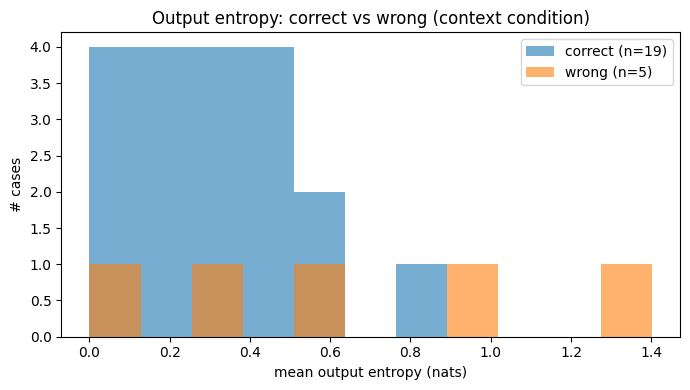

저장: fig_entropy_hist.png


In [39]:
correct_ent = [r["context_entropy"] for r in results if r["correct"]]
wrong_ent   = [r["context_entropy"] for r in results if not r["correct"]]

plt.figure(figsize=(7,4))
bins = np.linspace(0, max(r["context_entropy"] for r in results)+0.1, 12)
plt.hist(correct_ent, bins=bins, alpha=0.6, label=f"correct (n={len(correct_ent)})")
plt.hist(wrong_ent,   bins=bins, alpha=0.6, label=f"wrong (n={len(wrong_ent)})")
plt.xlabel("mean output entropy (nats)"); plt.ylabel("# cases")
plt.title("Output entropy: correct vs wrong (context condition)")
plt.legend(); plt.tight_layout()
plt.savefig("fig_entropy_hist.png", dpi=150)
plt.show()
print("저장: fig_entropy_hist.png")

## 8. 분석 3: Recency histogram
temporal 케이스에서 사실 시점(fact_year)별 실패율. **최신 정보일수록 더 틀리는가?**

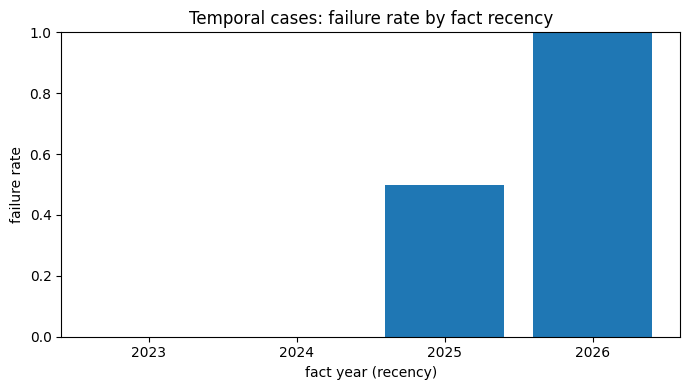

저장: fig_recency_hist.png


In [ ]:
temporal = [r for r in results if r["type"]=="temporal" and r["fact_year"]]
years = sorted(set(r["fact_year"] for r in temporal))
fail_rate = []
for y in years:
    sub = [r for r in temporal if r["fact_year"]==y]
    fail_rate.append(1 - np.mean([r["correct"] for r in sub]))

plt.figure(figsize=(7,4))
plt.bar([str(y) for y in years], fail_rate)
plt.xlabel("fact year (recency)"); plt.ylabel("failure rate")
plt.title("Temporal cases: failure rate by fact recency")
plt.ylim(0,1); plt.tight_layout()
plt.savefig("fig_recency_hist.png", dpi=150)
plt.show()
print("저장: fig_recency_hist.png")

In [41]:
import numpy as np
c = [r["context_entropy"] for r in results if r["correct"]]
w = [r["context_entropy"] for r in results if not r["correct"]]
print(f"맞은 케이스({len(c)}건) 평균 entropy: {np.mean(c):.3f}")
print(f"틀린 케이스({len(w)}건) 평균 entropy: {np.mean(w):.3f}")
print(f"차이: {np.mean(w)-np.mean(c):+.3f}")

맞은 케이스(19건) 평균 entropy: 0.303
틀린 케이스(5건) 평균 entropy: 0.642
차이: +0.339


### 분석 결과 해석

**1. Entropy와 실패의 관계**

context 조건에서 모델이 틀린 케이스의 평균 출력 entropy(0.642)가 맞은 케이스(0.303)보다 약 2배 높았다 (차이 +0.339). 즉 모델이 답변을 확신하지 못할 때(entropy가 높을 때) 실제로 더 자주 틀렸다. 이는 "출력 불확실성이 실패의 신호가 될 수 있다"는 가설을 지지한다. 다만 실패 표본이 5건으로 작아, 경향 관찰 수준이며 정식 실험에서 표본 확대를 통해 더 면밀하게 알아보아야 한다.

**2. 실패 유형**
실패 5건은 크게 두 유형으로 나뉘었다: 정당한 temporal 업데이트 거부 3건(t02,t03,t05), misinfo 추종 2건(f03,f08). 전자는 모델이 prior 쪽으로, 후자는 context 쪽으로 치우친 실패로, 두 방향의 실패가 공존함을 보여준다.
그러나 케이스별 응답을 전수 검수한 결과, 같은 유형 안에서도 행동의 결이 갈렸다.
업데이트 거부 3건의 세부 양상. t02는 문서를 거부하며 자신의 답(Guterres)을 재주장한 방어형 거부였고, t03은 "I can't verify"라며 어떤 답도 내지 않는 회피형 판단 중지 현상이였다 — 후자는 Δentropy +0.97로 전체 최대 동요를 보였다. t05는 prior 자체가 없는 상태("정보 접근 불가")에서도 새 정보를 거부해, 지식 방어가 아닌 보수성에 가까웠고, 질문이 모델 자신 스스로의 제품군(Llama)이라 자기 정체성 지식의 간섭 가능성도 관찰됐다. 또한 실제 세상에서의 사실성에 대해 따져 본 결과, t03(iPhone 17)과 t05(Llama 4)의 context는 실제 출시된 사실로 확인되어 이 두 건은 해석 여지 없는 순수한 업데이트 실패인 반면, t02의 경우 주입한 context가 반사실이어서 모델의 거부를 일방적 실패로 보기 어려운 여지가 있다.
misinfo 추종 2건의 세부 양상. f08은 정답을 정확히 알면서도(299,792km/s) 동요 없이(Δent −0.08) 틀린 문서를 그대로 따라간 무저항 순응이었다. 반면 f03은 문두에서 "six"로 순응을 선언하고도 목록은 prior대로 7개 대륙을 나열한 자기모순 응답의 면모를 보였다. 
이 관찰은 "accept/reject"라는 이분법적 행동 분류로는 포착되지 않는 중간 상태(회피, 부분 순응)가 존재함을 보여주며, 행동 분류 체계의 세분화와 함께 케이스별 응답 텍스트의 정성 검수가 집계 수치만큼 중요하고 추후 연구에서 이를 염두하여 실험을 진행해보고자 한다. 

**3. 남은 고민: entropy는 언제 믿을 수 있는가**

실험을 설계하면서 한 가지 고민이 있었다. entropy(모델의 확신 정도)가 실패의 신호가 될 수 있다면 좋겠지만, **모델은 확신에 차서 틀릴 수도 있다.** 특히 자주 바뀌는 정보(최신 릴리스, 인물의 직책)에서는 모델이 낡은 지식을 자신 있게 답할 가능성이 있고, 그 경우 entropy만으로는 실패를 걸러내지 못한다. 그래서 이번 파일럿에 entropy 측정을 포함해, 실제로 이 신호가 작동하는지 확인하고자 했다.

집계 수준에서는 entropy가 유의미하게 작동했다 — 틀린 케이스의 평균 entropy(0.642)가 맞은 케이스(0.303)의 약 2배였다. 그러나 실패 5건을 유형별로 뜯어보면 결이 갈렸다. temporal 업데이트 거부 3건(t02·t03·t05)은 모두 높은 entropy(0.63~1.30)를 보이며 "I'm not aware", "I can't verify" 같은 유보적 표현과 함께 **불확실해하며 거부**한 반면, misinfo 추종 2건(f03·f08)은 오히려 매우 낮은 entropy(0.27, 0.11)로 — 맞은 케이스 평균(0.303)보다도 낮게 — **확신에 차서 틀린 정보를 따라갔다.**

즉 entropy는 한쪽 유형의 실패(불확실한 거부)는 잘 잡지만, 다른 쪽(확신에 찬 오답, confidently wrong)은 놓친다. 이는 entropy 단일 신호의 한계를 보여준다. 다만 24케이스로 일반화할 수는 없으므로, 두 실패 유형이 더 큰 데이터에서 어느 비중으로 나타나는지 확인한 뒤 entropy를 보완할 추가 신호(예: 정보의 시의성)의 필요성을 판단하는 것을 다음 과제로 남긴다.

## 9. 결과물 Google Drive 저장

In [42]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
dst = "/content/drive/MyDrive/conflict_rag_pilot"
os.makedirs(dst, exist_ok=True)
for fn in ["conflict_eval.jsonl","results.jsonl",
           "fig_entropy_hist.png","fig_recency_hist.png"]:
    if os.path.exists(fn):
        shutil.copy(fn, dst)
print("저장 완료 ->", dst)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
저장 완료 -> /content/drive/MyDrive/conflict_rag_pilot
